#  Resume Screening App — Exploration NLP
**Pipeline complet : Dataset → Preprocessing → BERT Embeddings → Scoring → Ranking**


##  Cellule 1 — Installation des dépendances

In [16]:
# Fix complet pour Colab
!pip uninstall -y tensorflow tensorflow-text tensorflow_text -q
!pip install -q sentence-transformers==2.7.0
print(' Done — restart runtime maintenant !')

 Done — restart runtime maintenant !


##  Cellule 2 — Upload du dataset CSV

In [17]:
from google.colab import files
import pandas as pd



# Charger le CSV
filename = '/content/clean_resume_data.csv'
df = pd.read_csv(filename)
df.columns = [c.strip().lower() for c in df.columns]

print(f' Dataset chargé : {df.shape[0]} CVs, {df.shape[1]} colonnes')
print(f' Colonnes : {list(df.columns)}')
print(f'📂 Catégories : {df["category"].nunique()} uniques')
df.head(3)

 Dataset chargé : 2484 CVs, 3 colonnes
 Colonnes : ['id', 'category', 'feature']
📂 Catégories : 24 uniques


,id,category,feature
0,16852973,HR,hr administrator marketing associate hr admini...
1,22323967,HR,hr specialist hr operations summary media prof...
2,33176873,HR,hr director summary years experience recruitin...


##  Cellule 3 — Preprocessing (nettoyage texte)

In [18]:
import re

def clean_text(text):
    if not text or not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[@#]\S+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^\w\s\-]', ' ', text)
    text = re.sub(r'\b\d{4,}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# Appliquer sur tout le dataset
df['clean_text'] = df['feature'].apply(clean_text)

# Vérification
sample = df.iloc[0]
print(' Nettoyage terminé')
print(f'\n Exemple avant : {str(sample["feature"])[:200]}...')
print(f'\n Exemple après : {sample["clean_text"][:200]}...')

 Nettoyage terminé

 Exemple avant : hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused team...

 Exemple après : hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused team...


##  Cellule 4 — Chargement du modèle BERT

In [19]:
from sentence_transformers import SentenceTransformer

print(' Chargement du modèle BERT (all-MiniLM-L6-v2)...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(' Modèle BERT chargé !')

# Test rapide
test_vec = model.encode('data scientist python machine learning')
print(f'Dimension embedding : {test_vec.shape}')

 Chargement du modèle BERT (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Modèle BERT chargé !
🔢 Dimension embedding : (384,)


## Cellule 5 — Définir une offre d'emploi test

In [20]:
# ✏️ Tu peux modifier cette offre d'emploi
JOB_DESCRIPTION = """
We are looking for a Data Scientist with strong experience in Python,
machine learning, and NLP. Required skills: pandas, scikit-learn,
TensorFlow or PyTorch, SQL. Knowledge of BERT and transformers is a plus.
Experience with data visualization (matplotlib, seaborn) appreciated.
Strong communication skills and team player.
"""

job_clean = JOB_DESCRIPTION.lower().strip()
job_vector = model.encode(job_clean)

print(' Offre d\'emploi encodée')
print(f' Offre : {JOB_DESCRIPTION.strip()[:200]}...')

 Offre d'emploi encodée
 Offre : We are looking for a Data Scientist with strong experience in Python,
machine learning, and NLP. Required skills: pandas, scikit-learn,
TensorFlow or PyTorch, SQL. Knowledge of BERT and transformers i...


## Cellule 6 — Calcul des embeddings (batch) + similarité

In [21]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Limiter à 200 CVs pour la démo (sinon trop long)
SAMPLE_SIZE = 200
df_sample = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

print(f' Calcul embeddings pour {len(df_sample)} CVs...')
cv_vectors = model.encode(
    df_sample['clean_text'].tolist(),
    batch_size=32,
    show_progress_bar=True
)

# Calcul similarité cosinus
scores = cosine_similarity(cv_vectors, job_vector.reshape(1, -1)).flatten()
df_sample['semantic_score'] = scores

print(f'\n Scores calculés !')
print(f' Min: {scores.min():.3f} | Max: {scores.max():.3f} | Moy: {scores.mean():.3f}')

 Calcul embeddings pour 200 CVs...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


 Scores calculés !
 Min: 0.027 | Max: 0.337 | Moy: 0.178


##  Cellule 7 — Extraction des compétences

In [22]:
import json

# Skills database intégrée directement
SKILLS_DB = {
    'langages': ['python', 'java', 'javascript', 'sql', 'r', 'scala', 'bash', 'c++'],
    'frameworks_ml': ['tensorflow', 'pytorch', 'keras', 'scikit-learn', 'xgboost',
                      'hugging face', 'transformers', 'sentence-transformers', 'spacy', 'nltk'],
    'data': ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'spark'],
    'nlp': ['nlp', 'bert', 'gpt', 'word2vec', 'tf-idf', 'embeddings',
            'text classification', 'sentiment analysis'],
    'cloud_devops': ['aws', 'azure', 'docker', 'kubernetes', 'git', 'linux'],
    'bases_de_donnees': ['mysql', 'postgresql', 'mongodb', 'redis', 'sqlite'],
    'finance': ['finance', 'bloomberg', 'vba', 'risk management', 'trading']
}

def extract_skills_flat(text):
    text_lower = text.lower()
    found = []
    for skills_list in SKILLS_DB.values():
        for skill in skills_list:
            if skill in text_lower:
                found.append(skill)
    return list(set(found))

def match_skills(cv_text, job_text):
    cv_skills  = set(extract_skills_flat(cv_text))
    job_skills = set(extract_skills_flat(job_text))
    if not job_skills:
        return 0.0, [], []
    matched    = cv_skills & job_skills
    missing    = job_skills - cv_skills
    match_rate = len(matched) / len(job_skills)
    return match_rate, list(matched), list(missing)

# Appliquer sur le sample
df_sample['skills_rate'], df_sample['matched_skills'], df_sample['missing_skills'] = \
    zip(*df_sample['clean_text'].apply(lambda t: match_skills(t, job_clean)))

print(' Extraction compétences terminée')
print(f'Exemple skills matchées : {df_sample["matched_skills"].iloc[0]}')

 Extraction compétences terminée
Exemple skills matchées : ['r']


##  Cellule 8 — Score final + Classement

In [23]:
# Score final = 60% BERT + 40% Skills
df_sample['final_score'] = (
    df_sample['semantic_score'] * 0.60 +
    df_sample['skills_rate']    * 0.40
).round(4)

df_sample['percent'] = (df_sample['final_score'] * 100).round().astype(int)

def get_level(pct):
    if pct >= 75: return ' Excellent'
    elif pct >= 55: return ' Bon'
    elif pct >= 35: return ' Moyen'
    else: return 'Faible'

df_sample['niveau'] = df_sample['percent'].apply(get_level)

# Classement
df_ranked = df_sample.sort_values('final_score', ascending=False).reset_index(drop=True)
df_ranked['rang'] = df_ranked.index + 1

print(' Classement terminé !\n')
print('TOP 10 CANDIDATS')
print('=' * 60)
top10 = df_ranked[['rang', 'category', 'percent', 'niveau', 'matched_skills']].head(10)
print(top10.to_string(index=False))

 Classement terminé !

🏆 TOP 10 CANDIDATS
 rang    category  percent niveau   matched_skills
    1  CONSULTANT       26 Faible         [r, sql]
    2  CONSULTANT       26 Faible         [r, sql]
    3    AVIATION       24 Faible         [r, sql]
    4 ENGINEERING       24 Faible      [python, r]
    5  CONSULTANT       24 Faible         [r, sql]
    6  CONSULTANT       24 Faible         [r, sql]
    7  AUTOMOBILE       24 Faible              [r]
    8  CONSULTANT       23 Faible [python, r, sql]
    9    AVIATION       22 Faible [python, r, sql]
   10  CONSULTANT       22 Faible              [r]


##  Cellule 9 — Visualisations

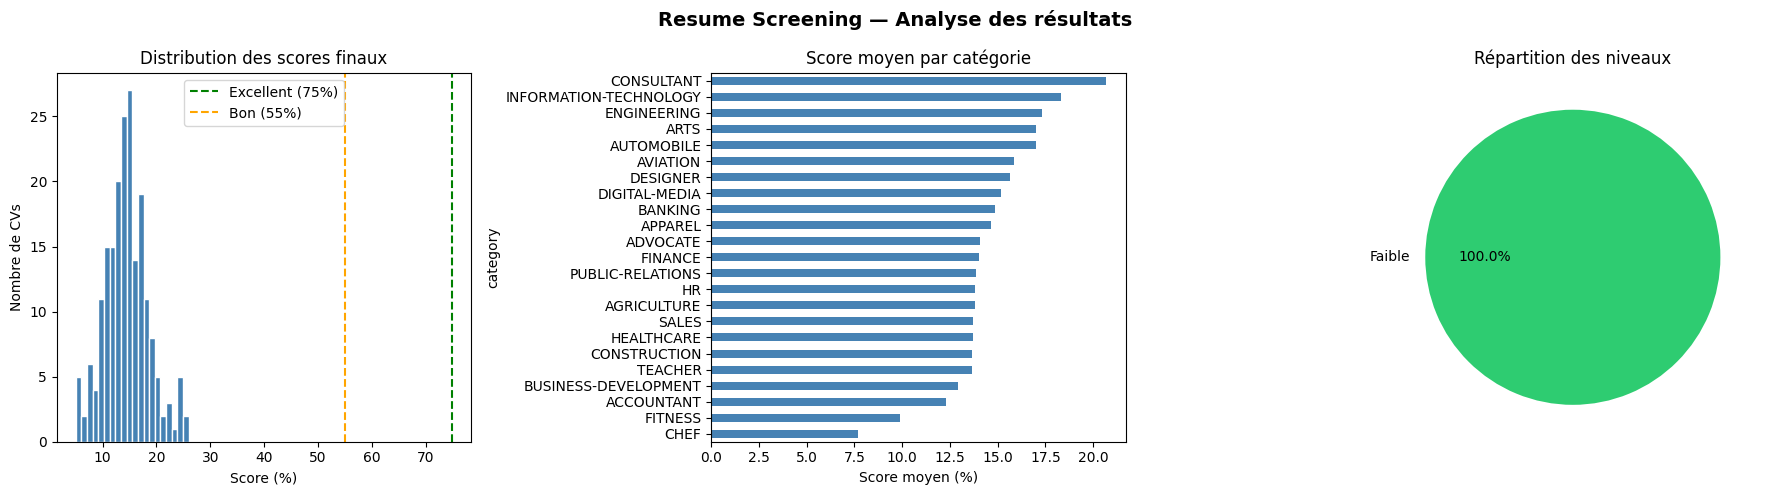

 Visualisations générées et sauvegardées !


In [26]:
import matplotlib.pyplot as plt
import matplotlib

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Resume Screening — Analyse des résultats', fontsize=14, fontweight='bold')

# ── Graphe 1 : Distribution des scores
axes[0].hist(df_ranked['percent'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des scores finaux')
axes[0].set_xlabel('Score (%)')
axes[0].set_ylabel('Nombre de CVs')
axes[0].axvline(x=75, color='green',  linestyle='--', label='Excellent (75%)')
axes[0].axvline(x=55, color='orange', linestyle='--', label='Bon (55%)')
axes[0].legend()

# ── Graphe 2 : Scores par catégorie
cat_scores = df_ranked.groupby('category')['percent'].mean().sort_values(ascending=True)
cat_scores.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Score moyen par catégorie')
axes[1].set_xlabel('Score moyen (%)')

# ── Graphe 3 : Répartition des niveaux
level_counts = df_ranked['niveau'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
axes[2].pie(
    level_counts.values,
    labels=level_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(level_counts)]
)
axes[2].set_title('Répartition des niveaux')

plt.tight_layout()
plt.savefig('results_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Visualisations générées et sauvegardées !')

## 💾 Cellule 10 — Export des résultats

In [ ]:
# Exporter le top 20 en CSV
export_cols = ['rang', 'category', 'percent', 'niveau', 'matched_skills', 'missing_skills']
df_export = df_ranked[export_cols].head(20)
df_export.to_csv('top20_candidates.csv', index=False)

# Télécharger les fichiers
files.download('top20_candidates.csv')
files.download('results_visualization.png')

print(' Fichiers exportés et téléchargés !')
print(f'\n Résumé final :')
print(f'  Total CVs analysés : {len(df_ranked)}')
print(f'  Score moyen        : {df_ranked["percent"].mean():.1f}%')
print(f'  Meilleur candidat  : {df_ranked.iloc[0]["percent"]}% ({df_ranked.iloc[0]["category"]})')
print(f'  Excellent match    : {(df_ranked["percent"] >= 75).sum()} candidats')
print(f'  Bon match          : {((df_ranked["percent"] >= 55) & (df_ranked["percent"] < 75)).sum()} candidats')